In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *
import time

In [2]:
N = 8
tau_r = get_tau_r(N)
wd = 2*np.pi / tau_r
wm = 1.0
t_max = 5000
tlist = np.linspace(0, t_max, 10000)
reals = 1
dis = 0.0

In [3]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.148, "omega": wd} # N=8 0.148, N=10 0.202, N=12 0.165

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

1 realizations in 0.8 s (0.78610 s per realization)


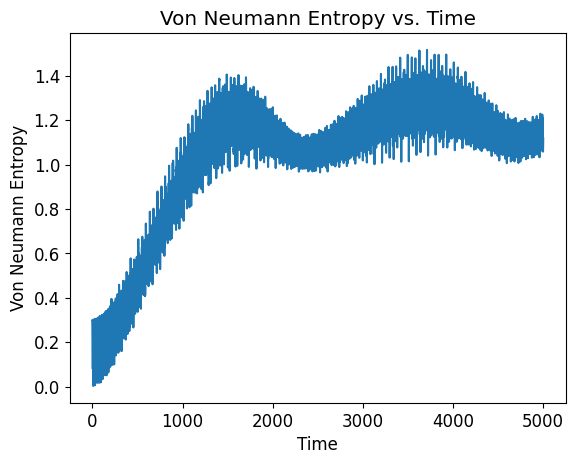

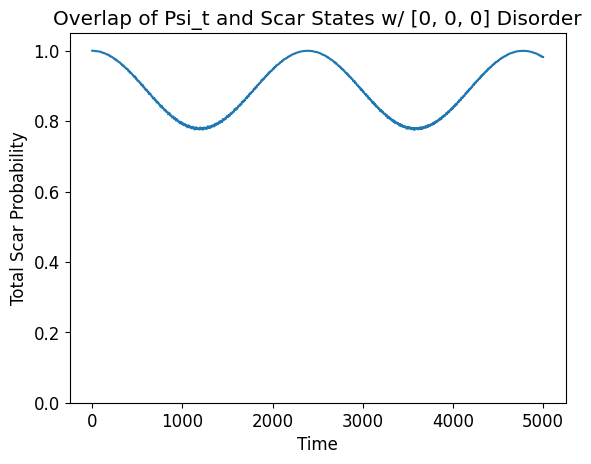

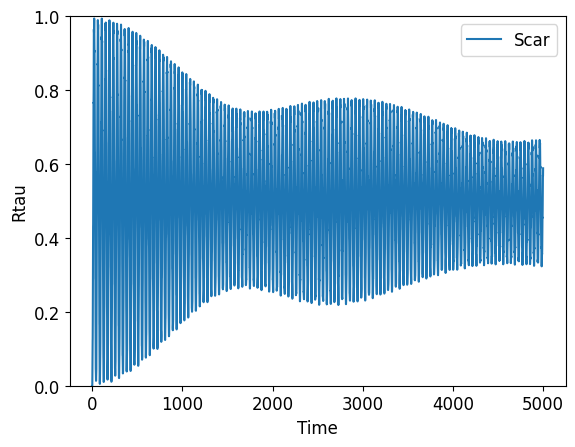

In [4]:
vn_plot = plot_scar_vn_entrop(N, wd, tlist=tlist, disorder=[0, 0, 0], reals=1, args=args)
scarIndices, scarStates = giveMeScarOverlap(N, psi0, tlist, disorder=[0, 0, 0], reals=1, args=args)
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.legend()
plt.ylim(0, 1)
plt.show()